# 02 — Analysis report (Deliverable B)

All tasks use the cleaned, joined table `master_train.csv` (Deliverable A): 82,742 zone-hours, 1 Jan – 31 Oct 2025, Addis local time.

**Comparison baseline used in B2 and B3.** "Expected" demand for a zone-hour = mean trips for the **same zone, month, weekday and hour** over *normal* hours: dry (observed weather, 0 mm), not a public holiday, and no event within ±6 h in that zone. Matching on month removes the Jan→Oct growth trend, which would otherwise make rainy-season hours look busier.

### Setup

In [1]:
import os
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.width", 160)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
PROC_DIR, RAW_DIR = ROOT / "data" / "processed", ROOT / "data" / "raw"

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_2, INK_3, GRID, SURFACE, NEUTRAL = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "lines.linewidth": 2,
})

d = pd.read_csv(PROC_DIR / "master_train.csv", parse_dates=["pickup_hour"])
events = pd.read_csv(PROC_DIR / "events_clean.csv", parse_dates=["start_datetime", "end_datetime"])
d["date"] = d["pickup_hour"].dt.normalize()
d["day_type"] = np.select([d["is_holiday"] == 1, d["is_weekend"] == 1], ["holiday", "weekend"], "weekday")
TYPE_ORDER = ["Business / office", "Mixed hub", "Market", "Residential", "Leisure / nightlife"]
active = events[events["is_cancelled"] == 0]
local = active[~active["event_type"].isin(["public_holiday", "school_break"])]
holidays = active[active["event_type"] == "public_holiday"].drop_duplicates("event_id")
print(d.shape, d["pickup_hour"].min(), "->", d["pickup_hour"].max())

(82742, 42) 2025-01-01 00:00:00 -> 2025-10-31 23:00:00


### Zone types (used in B1.2 and by notebooks 03 and 04)

Zones are grouped by the **shape** of their weekday hourly profile (each zone's curve divided by its own mean) with k-means; k is chosen by silhouette score. Names are given afterwards from each group's weekday peak hour and weekend ratio. Saved to `zone_types.csv`.

In [2]:
weekday_rows = d[(d["is_weekend"] == 0) & (d["is_holiday"] == 0)]
wk_prof = weekday_rows.groupby(["zone", "hour"])["trips"].mean().unstack()
shape = wk_prof.div(wk_prof.mean(axis=1), axis=0)
silhouette = {k: silhouette_score(shape, KMeans(k, n_init=20, random_state=0).fit_predict(shape)) for k in range(2, 7)}
best_k = max(silhouette, key=silhouette.get)
cluster = pd.Series(KMeans(best_k, n_init=20, random_state=0).fit_predict(shape), index=shape.index, name="cluster")
wr = d[d["is_holiday"] == 0].groupby(["zone", "is_weekend"])["trips"].mean().unstack()
per_zone = pd.DataFrame({"cluster": cluster, "peak_hour": wk_prof.idxmax(axis=1), "weekend_ratio": wr[1] / wr[0]})


def name_cluster(peak_hour, weekend_ratio):
    """Name a cluster from its weekday peak hour and weekend ratio."""
    if 11 <= peak_hour <= 15:
        return "Market (midday peak)"
    if weekend_ratio >= 1.2:
        return "Leisure / nightlife (late, weekend-heavy)"
    if weekend_ratio < 0.6:
        return "Business / office (weekday commute)"
    if weekend_ratio >= 1.0:
        return "Residential (evening peak, weekend >= weekday)"
    return "Mixed hub (commute + busy midday)"


names = per_zone.groupby("cluster").agg(peak_hour=("peak_hour", "median"), weekend_ratio=("weekend_ratio", "mean"))
names["zone_type"] = [name_cluster(r.peak_hour, r.weekend_ratio) for r in names.itertuples()]
per_zone["zone_type"] = per_zone["cluster"].map(names["zone_type"])
per_zone[["zone_type", "cluster"]].to_csv(PROC_DIR / "zone_types.csv", index_label="zone")
zone_type = per_zone["zone_type"].str.split(" \\(").str[0]
d["zone_type"] = d["zone"].map(zone_type)
print("silhouette by k:", {k: round(v, 3) for k, v in silhouette.items()}, "-> k =", best_k)
per_zone.sort_values(["zone_type", "weekend_ratio"]).round(3)

silhouette by k: {2: 0.541, 3: 0.624, 4: 0.631, 5: 0.751, 6: 0.623} -> k = 5


,cluster,peak_hour,weekend_ratio,zone_type
zone,,,,
Piassa,2,18,0.472,Business / office (weekday commute)
Arat Kilo,2,18,0.472,Business / office (weekday commute)
Kazanchis,2,18,0.485,Business / office (weekday commute)
Bole,4,6,1.344,"Leisure / nightlife (late, weekend-heavy)"
Merkato,1,13,0.880,Market (midday peak)
Megenagna,3,18,0.809,Mixed hub (commute + busy midday)
Lideta,3,18,0.815,Mixed hub (commute + busy midday)
Ayat,0,7,1.055,"Residential (evening peak, weekend >= weekday)"
Kolfe,0,7,1.076,"Residential (evening peak, weekend >= weekday)"


In [3]:
def hours_around(df, before_h, after_h):
    """One row per zone-hour from start - before_h to end + after_h for each event row."""
    return pd.concat([pd.DataFrame({"zone": r.zone, "event_id": r.event_id,
                                    "pickup_hour": pd.date_range(r.start_datetime.floor("h") - pd.Timedelta(hours=before_h),
                                                                 r.end_datetime.ceil("h") + pd.Timedelta(hours=after_h - 1), freq="h")})
                      for r in df.itertuples()], ignore_index=True)


blocked = hours_around(local, 6, 6)[["zone", "pickup_hour"]].drop_duplicates().assign(near_event=1)
d = d.merge(blocked, on=["zone", "pickup_hour"], how="left").fillna({"near_event": 0})
d["observed_weather"] = (d["weather_imputed"] == 0) & (d["is_forecast"] == 0)
normal = (d["near_event"] == 0) & (d["is_holiday"] == 0) & d["observed_weather"] & (d["rain_mm"] == 0)
expected = d[normal].groupby(["zone", "month", "dow", "hour"])["trips"].mean().rename("expected")
d = d.join(expected, on=["zone", "month", "dow", "hour"])
print(f"normal hours: {normal.mean():.1%} of rows | expected available for {d['expected'].notna().mean():.1%} of rows")


def window_ratio(ev, start_fn, end_fn):
    """Per event: actual trips / expected trips over its window in its zone (hours with no data skipped)."""
    rows = []
    for r in ev.itertuples():
        hrs = pd.date_range(start_fn(r), end_fn(r) - pd.Timedelta(hours=1), freq="h")
        g = d[(d["zone"] == r.zone) & d["pickup_hour"].isin(hrs) & d["expected"].notna()]
        if len(g):
            rows.append({"event_id": r.event_id, "event_type": r.event_type, "zone": r.zone,
                         "start": r.start_datetime, "hours": len(g), "ratio": g["trips"].sum() / g["expected"].sum()})
    return pd.DataFrame(rows)


def boot_ci(x, n=2000, seed=0):
    """95% bootstrap interval of the mean."""
    rng = np.random.default_rng(seed)
    means = [rng.choice(x, len(x)).mean() for _ in range(n)]
    return np.percentile(means, [2.5, 97.5])

normal hours: 80.0% of rows | expected available for 99.1% of rows


## B1 — Demand patterns

### B1.1 Volume by zone

In [4]:
days_open = d.groupby("zone")["date"].agg(["min", "nunique"])
b11 = d.groupby("zone").agg(total_trips=("trips", "sum"), zone_hours=("trips", "size"), mean_per_zone_hour=("trips", "mean"))
b11["share_pct"] = 100 * b11["total_trips"] / b11["total_trips"].sum()
b11["first_day"] = days_open["min"].dt.strftime("%d %b")
b11 = b11.sort_values("mean_per_zone_hour", ascending=False).round(1)
b11

,total_trips,zone_hours,mean_per_zone_hour,share_pct,first_day
zone,,,,,
Merkato,283912,7010,40.5,12.1,01 Jan
Bole,276178,7037,39.2,11.7,01 Jan
Megenagna,268948,7034,38.2,11.4,01 Jan
Kazanchis,223162,7034,31.7,9.5,01 Jan
Piassa,199012,7044,28.3,8.5,01 Jan
Lideta,197503,7052,28.0,8.4,01 Jan
CMC,181736,7060,25.7,7.7,01 Jan
Gerji,169922,7024,24.2,7.2,01 Jan
Kolfe,161461,7039,22.9,6.9,01 Jan


**Interpretation.** Merkato (12.1% of trips), Bole (11.7%) and Megenagna (11.4%) carry the most demand, each averaging about 38–41 trips per zone-hour; together they are over a third of the city. Ayat only started on 15 March, so its 4.0% share of total trips understates it — compare zones on mean trips per zone-hour (Ayat 17.8, the lowest, over about 1,700 fewer hours).

### B1.2 Hour-of-day profile by zone type (weekdays)

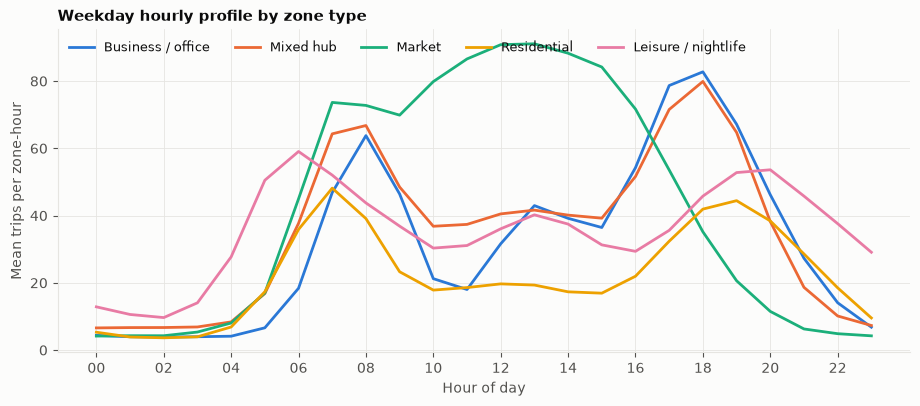

,zones,morning peak,afternoon/evening peak,quietest,peak ÷ quietest
zone_type,,,,,
Business / office,"Arat Kilo, Kazanchis, Piassa",08:00 (64),18:00 (83),02:00 (3.9),21.4
Mixed hub,"Lideta, Megenagna",08:00 (67),18:00 (80),00:00 (6.6),12.1
Market,Merkato,11:00 (87),13:00 (91),00:00 (4.2),21.8
Residential,"Ayat, CMC, Gerji, Kolfe, Sarbet",07:00 (48),19:00 (44),02:00 (3.7),13.2
Leisure / nightlife,Bole,06:00 (59),20:00 (54),02:00 (9.7),6.1


In [5]:
wk = d[d["day_type"] == "weekday"]
prof = wk.groupby(["zone_type", "hour"])["trips"].mean().unstack()
b12 = pd.DataFrame({
    "zones": [", ".join(sorted(zone_type.index[zone_type == t])) for t in prof.index],
    "morning peak": [f"{prof.loc[t, 5:11].idxmax():02d}:00 ({prof.loc[t, 5:11].max():.0f})" for t in prof.index],
    "afternoon/evening peak": [f"{prof.loc[t, 12:23].idxmax():02d}:00 ({prof.loc[t, 12:23].max():.0f})" for t in prof.index],
    "quietest": [f"{prof.loc[t].idxmin():02d}:00 ({prof.loc[t].min():.1f})" for t in prof.index],
    "peak ÷ quietest": (prof.max(axis=1) / prof.min(axis=1)).round(1).values,
}, index=prof.index).loc[TYPE_ORDER]
fig, ax = plt.subplots(figsize=(11, 4.2))
for color, t in zip(SERIES, TYPE_ORDER):
    ax.plot(prof.columns, prof.loc[t], color=color, label=t)
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean trips per zone-hour")
ax.legend(frameon=False, ncol=5, loc="upper left", fontsize=9)
ax.set_title("Weekday hourly profile by zone type")
plt.show()
b12

**Interpretation.** Business zones (Arat Kilo, Kazanchis, Piassa) and the mixed hubs (Lideta, Megenagna) have twin commute peaks at 08:00 and 18:00, with the evening peak larger. Merkato is a market: one long daytime plateau peaking at 11:00–13:00 (about 91 trips) and almost nothing at night. Residential zones peak earliest in the morning (07:00) and again at 19:00. Bole is the only zone with real night-time demand (quietest hour still about 10 trips) and a late evening peak at 20:00. Every type is quietest at 00:00–02:00.

### B1.3 Weekday vs weekend

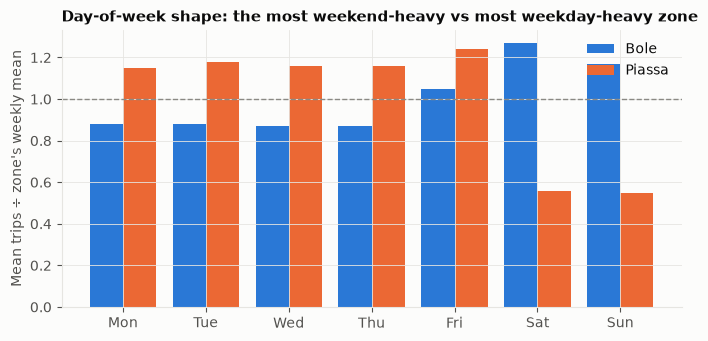

         Mon   Tue   Wed   Thu   Fri   Sat   Sun
zone                                            
Bole    0.88  0.88  0.87  0.87  1.05  1.27  1.17
Piassa  1.15  1.18  1.16  1.16  1.24  0.56  0.55


,zone type,weekday mean,weekend mean,weekend ÷ weekday
zone,,,,
Piassa,Business / office,33.84,15.96,0.47
Arat Kilo,Business / office,24.54,11.59,0.47
Kazanchis,Business / office,37.85,18.34,0.48
Megenagna,Mixed hub,40.67,32.91,0.81
Lideta,Mixed hub,29.78,24.27,0.81
Merkato,Market,42.80,37.65,0.88
Ayat,Residential,17.54,18.49,1.05
Kolfe,Residential,22.43,24.14,1.08
CMC,Residential,25.15,27.18,1.08


In [6]:
nh = d[d["is_holiday"] == 0]
m = nh.groupby(["zone", "is_weekend"])["trips"].mean().unstack()
b13 = pd.DataFrame({"zone type": zone_type, "weekday mean": m[0], "weekend mean": m[1],
                    "weekend ÷ weekday": m[1] / m[0]}).sort_values("weekend ÷ weekday").round(2)
dow = nh[nh["zone"].isin(["Bole", "Piassa"])].groupby(["zone", "dow"])["trips"].mean().unstack(0)
dow_index = (dow / dow.mean()).round(2)
dow_index.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(7)
ax.bar(x - 0.2, dow_index["Bole"], 0.4, color=BLUE, label="Bole")
ax.bar(x + 0.2, dow_index["Piassa"], 0.4, color=ORANGE, label="Piassa")
ax.axhline(1, color=INK_3, linestyle="--", linewidth=1)
ax.set_xticks(x, dow_index.index)
ax.set_ylabel("Mean trips ÷ zone's weekly mean")
ax.legend(frameon=False)
ax.set_title("Day-of-week shape: the most weekend-heavy vs most weekday-heavy zone")
plt.show()
print(dow_index.T.to_string())
b13

**Interpretation.** Business zones collapse at weekends to about 0.47× their weekday demand, Merkato and the mixed hubs dip moderately (0.81–0.88×), residential zones are slightly busier at weekends (1.05–1.09×), and Bole is 34% busier (1.34×). Bole stands out: Monday–Thursday run at 0.87–0.88 of its weekly mean, Friday rises to 1.05 and Saturday peaks at 1.27 — the mirror image of Piassa, which falls from 1.15–1.24 on weekdays to 0.55 at weekends.

### B1.4 Trend

11 zones open all year, weekly trips (scaled to full coverage): first 4 full weeks 44,534/week -> last 4 62,046/week = +39.3%
linear trend: +517 trips per week, every week (+0.96% of an average week)
all 12 zones, last full week (2025-10-20/2025-10-26): 63,768 trips
straight-line extrapolation: first two weeks of November ≈ 63,338 trips/week for the 11 zones


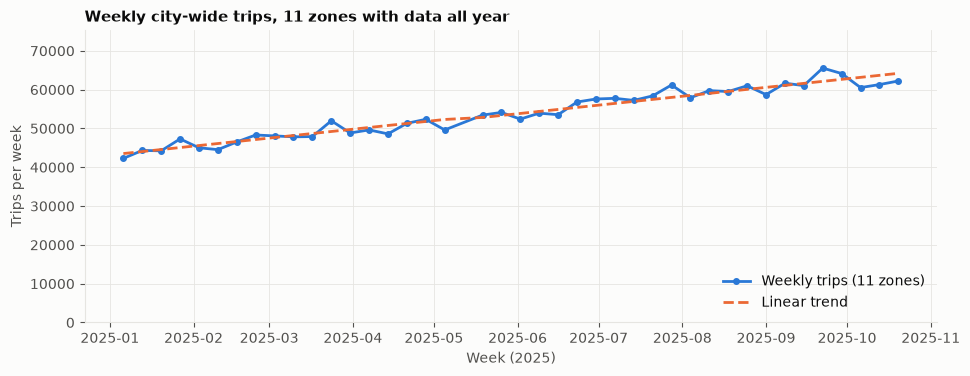

In [7]:
steady = d[d["zone"] != "Ayat"]
wkly = steady.groupby(steady["date"].dt.to_period("W-SUN")).agg(trips=("trips", "sum"), zone_hours=("trips", "size"))
wkly = wkly[wkly["zone_hours"] >= 0.9 * 11 * 168]
wkly["trips_full_coverage"] = wkly["trips"] / wkly["zone_hours"] * 11 * 168
first4, last4 = wkly["trips_full_coverage"].iloc[:4].mean(), wkly["trips_full_coverage"].iloc[-4:].mean()
slope = np.polyfit(np.arange(len(wkly)), wkly["trips_full_coverage"], 1)[0]
city_week = d.groupby(d["date"].dt.to_period("W-SUN"))["trips"].sum()
print(f"11 zones open all year, weekly trips (scaled to full coverage): first 4 full weeks {first4:,.0f}/week -> last 4 {last4:,.0f}/week "
      f"= {100 * (last4 / first4 - 1):+.1f}%")
print(f"linear trend: {slope:+,.0f} trips per week, every week ({100 * slope / wkly['trips_full_coverage'].mean():+.2f}% of an average week)")
print(f"all 12 zones, last full week ({city_week.index[-2]}): {city_week.iloc[-2]:,.0f} trips")
print(f"straight-line extrapolation: first two weeks of November ≈ {last4 + slope * 2.5:,.0f} trips/week for the 11 zones")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(wkly.index.to_timestamp(), wkly["trips_full_coverage"], color=BLUE, marker="o", markersize=4, label="Weekly trips (11 zones)")
xs = np.arange(len(wkly))
ax.plot(wkly.index.to_timestamp(), np.polyval(np.polyfit(xs, wkly["trips_full_coverage"], 1), xs), color=ORANGE, linestyle="--", label="Linear trend")
ax.set_ylim(0, wkly["trips_full_coverage"].max() * 1.15)
ax.set_xlabel("Week (2025)")
ax.set_ylabel("Trips per week")
ax.legend(frameon=False, loc="lower right")
ax.set_title("Weekly city-wide trips, 11 zones with data all year")
plt.show()

**Interpretation.** City demand grew steadily: the 11 zones with data all year went from about 44,500 trips per week in January to about 62,000 in October (+39%), a straight-line gain of about 517 trips per week, every week. A November forecast should therefore sit at or slightly above late-October levels (about 63,000 trips per week for those 11 zones), not at the January–October average; a model without a trend or recent-level feature would under-forecast.

## B2 — Weather

### B2.1 Timezone check

temperature peaks at 12:00 on the raw clock and 15:00 after +3 h (minimum 00:00 raw vs 03:00 corrected)


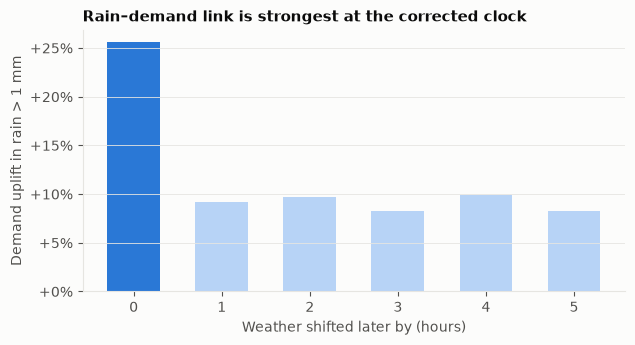

,rainy-hour demand ratio,"corr(rain_mm, trips ÷ expected)"
shift (h),,
0,1.256,0.246
1,1.092,0.051
2,1.097,0.055
3,1.083,0.041
4,1.099,0.040
5,1.083,0.029


In [8]:
raw_w = pd.read_csv(RAW_DIR / "weather_hourly.csv")
raw_w["temp"] = np.where(raw_w["temp_c"] > 40, (raw_w["temp_c"] - 32) * 5 / 9, raw_w["temp_c"])
z = raw_w["timestamp"].str.endswith("Z")
utc_hour = pd.to_datetime(raw_w.loc[z, "timestamp"], format="%Y-%m-%dT%H:%M:%SZ").dt.hour
peak_raw = raw_w.loc[z].groupby(utc_hour)["temp"].mean()
weather = pd.read_csv(PROC_DIR / "weather_clean.csv", parse_dates=["timestamp"])
peak_eat = weather[weather["weather_imputed"] == 0].groupby(weather["timestamp"].dt.hour)["temp_c"].mean()
print(f"temperature peaks at {peak_raw.idxmax():02d}:00 on the raw clock and {peak_eat.idxmax():02d}:00 after +3 h "
      f"(minimum {peak_raw.idxmin():02d}:00 raw vs {peak_eat.idxmin():02d}:00 corrected)")

rows = []
base_rows = d[(d["near_event"] == 0) & (d["is_holiday"] == 0) & d["expected"].notna()][["zone", "pickup_hour", "trips", "expected"]]
for k in range(0, 6):
    w = weather.assign(pickup_hour=weather["timestamp"] + pd.Timedelta(hours=k))
    x = base_rows.merge(w[["pickup_hour", "rain_mm", "weather_imputed"]], on="pickup_hour")
    x = x[x["weather_imputed"] == 0]
    rainy = x["rain_mm"] > 1
    rows.append({"shift (h)": k, "rainy-hour demand ratio": x.loc[rainy, "trips"].sum() / x.loc[rainy, "expected"].sum(),
                 "corr(rain_mm, trips ÷ expected)": x["rain_mm"].corr(x["trips"] / x["expected"])})
b21 = pd.DataFrame(rows).set_index("shift (h)").round(3)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(b21.index, b21["rainy-hour demand ratio"] - 1, color=[BLUE if k == 0 else "#b7d3f6" for k in b21.index], width=0.6)
ax.set_xlabel("Weather shifted later by (hours)")
ax.set_ylabel("Demand uplift in rain > 1 mm")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.grid(axis="x", visible=False)
ax.set_title("Rain–demand link is strongest at the corrected clock")
plt.show()
b21

**Interpretation.** Weather timestamps are UTC: on the raw clock temperature peaks at 12:00 and bottoms at 00:00, which is solar noon and midnight in UTC; after +3 h it peaks at 15:00 and bottoms at 03:00, as expected in Addis. The rain–demand link is sharp only on the corrected clock: rainy hours (> 1 mm) run 26% above normal with the clocks aligned, but only 8–10% when weather is shifted by 1–5 hours, and the correlation drops from 0.25 to 0.03–0.06. A 3-hour clock error would have hidden most of the rain effect.

### B2.2 Rain effect by zone type

In [9]:
rain_rows = d[(d["near_event"] == 0) & (d["is_holiday"] == 0) & d["observed_weather"] & d["expected"].notna()]
rainy = rain_rows[rain_rows["rain_mm"] > 0]
b22 = rainy.groupby("zone_type")[["trips", "expected"]].sum().assign(ratio=lambda t: t["trips"] / t["expected"])
b22["rainy zone-hours"] = rainy.groupby("zone_type").size()
by_zone = rainy.groupby("zone")[["trips", "expected"]].sum().pipe(lambda t: t["trips"] / t["expected"]).round(3)
print("ratio by zone:", by_zone.sort_values().to_dict())
b22.loc[TYPE_ORDER].round(3)

ratio by zone: {'Merkato': 0.781, 'Megenagna': 1.251, 'Gerji': 1.258, 'Lideta': 1.261, 'CMC': 1.264, 'Bole': 1.264, 'Piassa': 1.265, 'Kazanchis': 1.27, 'Arat Kilo': 1.275, 'Sarbet': 1.281, 'Kolfe': 1.288, 'Ayat': 1.296}


,trips,expected,ratio,rainy zone-hours
zone_type,,,,
Business / office,70759,55741.917,1.269,1323
Mixed hub,56765,45230.917,1.255,942
Market,20831,26662.833,0.781,471
Residential,87901,68925.250,1.275,2308
Leisure / nightlife,19168,15164.500,1.264,360


**Interpretation.** No — rain raises demand in 11 of 12 zones by a remarkably similar 25–30% versus the same zone, month, weekday and hour in dry weather, but Merkato drops to 0.78×. A market is an outdoor destination: rain cancels the trip rather than replacing walking with a ride.

### B2.3 Rain dose-response

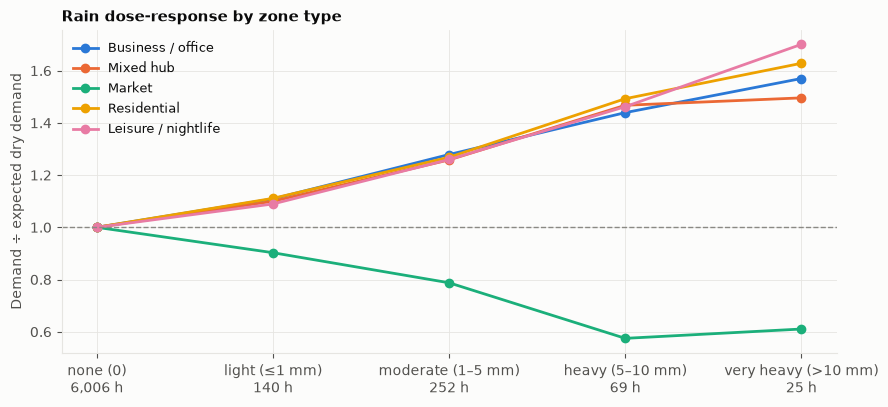

rain_class,none (0),light (≤1 mm),moderate (1–5 mm),heavy (5–10 mm),very heavy (>10 mm)
zone_type,,,,,
Business / office,1.0,1.109,1.279,1.439,1.570
Mixed hub,1.0,1.100,1.258,1.467,1.496
Market,1.0,0.903,0.788,0.575,0.610
Residential,1.0,1.111,1.268,1.493,1.628
Leisure / nightlife,1.0,1.089,1.260,1.462,1.701


In [10]:
CLASSES = ["none (0)", "light (≤1 mm)", "moderate (1–5 mm)", "heavy (5–10 mm)", "very heavy (>10 mm)"]
rr = rain_rows.assign(rain_class=pd.cut(rain_rows["rain_mm"], [-0.01, 0, 1, 5, 10, np.inf], labels=CLASSES))
b23 = (rr.groupby(["zone_type", "rain_class"], observed=True)[["trips", "expected"]].sum()
         .pipe(lambda t: t["trips"] / t["expected"]).unstack()[CLASSES].loc[TYPE_ORDER])
hours_per_class = rr.groupby("rain_class", observed=True)["pickup_hour"].nunique()
fig, ax = plt.subplots(figsize=(10, 4.2))
for color, t in zip(SERIES, TYPE_ORDER):
    ax.plot(range(len(CLASSES)), b23.loc[t], color=color, marker="o", markersize=6, label=t)
ax.axhline(1, color=INK_3, linestyle="--", linewidth=1)
ax.set_xticks(range(len(CLASSES)), [f"{c}\n{hours_per_class[c]:,} h" for c in CLASSES])
ax.set_ylabel("Demand ÷ expected dry demand")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Rain dose-response by zone type")
plt.show()
b23.round(3)

**Interpretation.** The response is not proportional to rainfall. Demand rises steeply at first (+10% in light rain, +26–28% in 1–5 mm, +44–49% in 5–10 mm) and then flattens: above 10 mm the mixed hubs barely move further (1.47 → 1.50) and business zones add only another 13 points, while Bole and residential zones keep climbing to 1.63–1.70. Merkato falls in the opposite direction and bottoms out around 0.58–0.61 at heavy rain. A rain-class feature captures this better than raw millimetres.

## B3 — Events & calendar

### B3.1 Public holidays

                     holiday       date weekday  city index
0                Good Friday 2025-04-18     Fri        72.9
1                      Genna 2025-01-07     Tue        75.4
2      Patriots' Victory Day 2025-05-05     Mon        75.5
3                Eid al-Adha 2025-06-06     Fri        77.6
4                     Mawlid 2025-09-04     Thu        81.0
5                Eid al-Fitr 2025-03-31     Mon        82.5
6       Downfall of the Derg 2025-05-28     Wed        82.7
7                 Enkutatash 2025-09-11     Thu        83.6
8   International Labour Day 2025-05-01     Thu        85.0
9                     Meskel 2025-09-27     Sat        96.7
10                    Fasika 2025-04-20     Sun        97.8
11                    Timkat 2025-01-19     Sun       101.3
12          Adwa Victory Day 2025-03-02     Sun       104.5

mean holiday index by zone (weekday holidays only):
Piassa        46.8
Arat Kilo     47.6
Kazanchis     48.5
Merkato       52.3
Lideta        80.4
Megenagna   

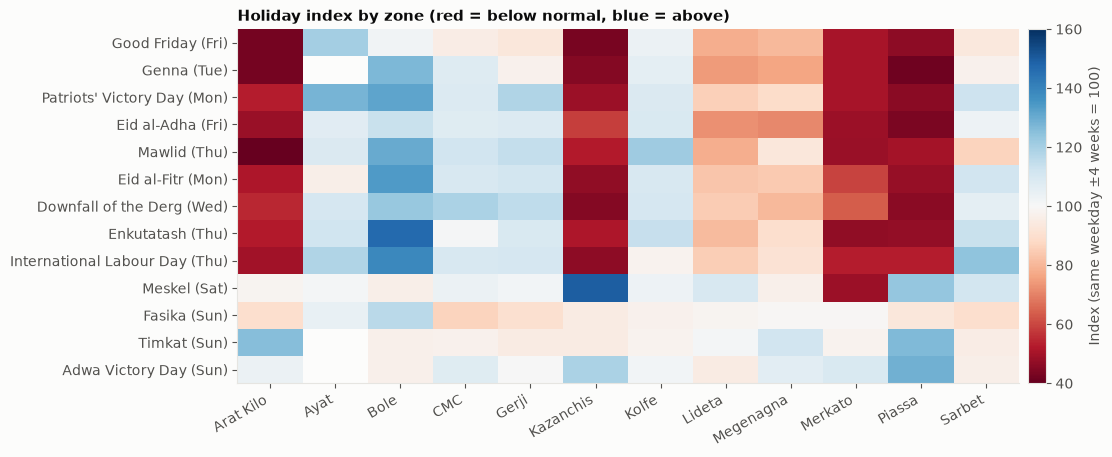

In [11]:
def daily_index(frame):
    """Daily mean trips per zone-hour (days with >= 80% coverage)."""
    g = frame.groupby("date")["trips"].agg(["mean", "size"])
    return g[g["size"] >= 0.8 * 24 * frame["zone"].nunique()]["mean"]


holiday_dates = set(holidays["start_datetime"].dt.normalize())


def holiday_ratio(series, date):
    """Value on the holiday ÷ mean of the same weekday ±4 weeks (non-holidays)."""
    ref = series.reindex([date + pd.Timedelta(weeks=k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)])
    ref = ref[~ref.index.isin(holiday_dates)].dropna()
    return series.get(date, np.nan) / ref.mean() if len(ref) else np.nan


city = daily_index(d[d["zone"] != "Ayat"])
b31 = pd.DataFrame([{"holiday": h.event_name.split(" (")[0], "date": h.start_datetime.normalize(),
                     "weekday": f"{h.start_datetime:%a}", "city index": 100 * holiday_ratio(city, h.start_datetime.normalize())}
                    for h in holidays.itertuples()]).sort_values("city index").reset_index(drop=True)
zone_daily = d.groupby(["zone", "date"])["trips"].mean().unstack(0)
local_idx = pd.DataFrame({z: [100 * holiday_ratio(zone_daily[z].dropna(), dt) for dt in b31["date"]] for z in zone_daily}, index=b31["holiday"])
print(b31.round(1).to_string())
print("\nmean holiday index by zone (weekday holidays only):")
weekday_hol = b31["weekday"].isin(["Mon", "Tue", "Wed", "Thu", "Fri"]).values
print(local_idx[weekday_hol].mean().sort_values().round(1).to_string())
fig, ax = plt.subplots(figsize=(12, 4.6))
im = ax.imshow(local_idx.values, aspect="auto", cmap="RdBu", vmin=40, vmax=160)
ax.set_xticks(range(len(local_idx.columns)), local_idx.columns, rotation=30, ha="right")
ax.set_yticks(range(len(local_idx)), [f"{h} ({w})" for h, w in zip(local_idx.index, b31["weekday"])])
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("Index (same weekday ±4 weeks = 100)", color=INK_2)
ax.set_title("Holiday index by zone (red = below normal, blue = above)")
plt.show()

**Interpretation.** Every holiday that falls on a weekday cuts city demand to 73–85% of the same weekday in nearby weeks (Good Friday lowest at 73%); the four weekend holidays (Meskel on a Saturday; Fasika, Timkat and Adwa on Sundays) are within ±5% of a normal weekend day, so not all holidays reduce demand. The reaction is local: on weekday holidays the business zones and Merkato fall to about half (Piassa 47, Arat Kilo 48, Kazanchis 49, Merkato 52), the mixed hubs dip to 80–84, while residential zones rise 5–13% and Bole rises 27% — people stay home or go out instead of commuting.

### B3.2 Event-window study (football)

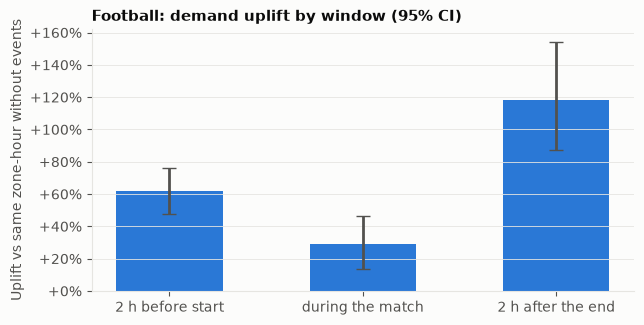

,matches,mean ratio,median ratio,95% CI low,95% CI high
window,,,,,
2 h before start,32,1.616,1.645,1.476,1.761
during the match,35,1.291,1.141,1.139,1.464
2 h after the end,35,2.183,1.952,1.874,2.544


In [12]:
football = local[local["event_type"] == "football_match"]
windows = {
    "2 h before start": (lambda r: r.start_datetime - pd.Timedelta(hours=2), lambda r: r.start_datetime),
    "during the match": (lambda r: r.start_datetime, lambda r: r.end_datetime),
    "2 h after the end": (lambda r: r.end_datetime, lambda r: r.end_datetime + pd.Timedelta(hours=2)),
}
b32 = []
for name, (a, b) in windows.items():
    w = window_ratio(football, a, b)
    lo, hi = boot_ci(w["ratio"].values)
    b32.append({"window": name, "matches": len(w), "mean ratio": w["ratio"].mean(), "median ratio": w["ratio"].median(),
                "95% CI low": lo, "95% CI high": hi})
b32 = pd.DataFrame(b32).set_index("window")
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(b32.index, b32["mean ratio"] - 1, yerr=[b32["mean ratio"] - b32["95% CI low"], b32["95% CI high"] - b32["mean ratio"]],
       color=BLUE, width=0.55, capsize=5, error_kw=dict(ecolor=INK_2))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_ylabel("Uplift vs same zone-hour without events")
ax.grid(axis="x", visible=False)
ax.set_title("Football: demand uplift by window (95% CI)")
plt.show()
b32.round(3)

**Interpretation.** The largest uplift is after the match: in the 2 hours after the end, demand in the stadium zone is 2.2× a normal zone-hour (95% CI 1.9–2.5), versus 1.6× in the 2 hours before kick-off and only 1.3× during the match (the median during is 1.14). Crowds arrive spread out but all leave at once, so the post-match exit surge is the window to staff for.

### B3.3 Event type ranking

In [13]:
rows = []
for etype, g in local.groupby("event_type"):
    w = window_ratio(g, lambda r: r.start_datetime - pd.Timedelta(hours=2), lambda r: r.end_datetime + pd.Timedelta(hours=2))
    if len(w):
        lo, hi = boot_ci(w["ratio"].values) if len(w) > 2 else (np.nan, np.nan)
        rows.append({"event type": etype, "events": len(w), "effect (ratio)": w["ratio"].mean(), "95% CI low": lo, "95% CI high": hi})
b33 = pd.DataFrame(rows).sort_values("effect (ratio)", ascending=False).set_index("event type")
b33["measurable?"] = np.where(b33["events"] < 3, "too few events", np.where((b33["95% CI low"] > 1) | (b33["95% CI high"] < 1), "yes", "no"))
b33.round(3)

,events,effect (ratio),95% CI low,95% CI high,measurable?
event type,,,,,
football_match,36,1.723,1.554,1.898,yes
concert,25,1.261,1.214,1.307,yes
conference,35,1.201,1.127,1.275,yes
exhibition,7,1.007,0.964,1.039,no
sports_run,2,0.844,NaN,NaN,too few events
road_closure,25,0.789,0.738,0.838,yes


**Interpretation.** Football matches have the largest effect (1.72× over the window from 2 h before to 2 h after), followed by concerts (1.26×) and conferences (1.20×); all three are clearly measurable. Road closures reduce demand to 0.79× in the closed zone. Exhibitions show no measurable effect (1.01×, CI 0.96–1.04): spread over several days, their visitors do not concentrate in any hour. Sports runs (2 events, 0.84×) are too few to judge.

### B3.4 Cancelled and unlisted events

In [14]:
cancelled = events[events["is_cancelled"] == 1].drop_duplicates("event_id")
b34a = window_ratio(cancelled, lambda r: r.start_datetime - pd.Timedelta(hours=2), lambda r: r.end_datetime + pd.Timedelta(hours=2))
b34a = b34a.merge(cancelled[["event_id", "event_name"]], on="event_id")
overlap = []
for r in cancelled.itertuples():
    o = active[(active["zone"] == r.zone) & (active["start_datetime"] < r.end_datetime + pd.Timedelta(hours=2))
               & (active["end_datetime"] > r.start_datetime - pd.Timedelta(hours=2))]
    overlap.append(", ".join(o["event_id"] + " " + o["event_type"]) or "none")
b34a["active event overlapping"] = overlap[:len(b34a)] if len(overlap) == len(b34a) else None
x = d[(d["near_event"] == 0) & (d["is_holiday"] == 0) & d["expected"].notna() & (d["expected"] >= 10)].copy()
x["ratio"] = x["trips"] / x["expected"]
print("cancelled events, actual ÷ expected over [start − 2 h, end + 2 h):")
print(b34a[["event_id", "event_name", "zone", "start", "ratio", "active event overlapping"]].round(2).to_string(index=False))
print(f"\nfor reference, 95% of normal zone-hours have a ratio between {x['ratio'].quantile(0.025):.2f} and {x['ratio'].quantile(0.975):.2f}")

cancelled events, actual ÷ expected over [start − 2 h, end + 2 h):
event_id                  event_name      zone               start  ratio active event overlapping
EVT-0020        Premier league match Kazanchis 2025-02-22 15:00:00   1.61  EVT-0021 football_match
EVT-0042 Conference: Health congress Kazanchis 2025-04-03 08:00:00   0.94                     none
EVT-0052        Premier league match Kazanchis 2025-04-23 18:00:00   1.11                     none
EVT-0058        Premier league match Kazanchis 2025-05-03 15:00:00   0.91                     none
EVT-0099                Live concert      Bole 2025-07-28 20:00:00   1.14    EVT-0096 school_break
EVT-0113                Live concert      Bole 2025-09-01 20:00:00   1.14         EVT-0114 concert

for reference, 95% of normal zone-hours have a ratio between 0.62 and 1.57


In [15]:
spikes = x[(x["ratio"] > 1.8) & (x["rain_mm"] == 0)]
by_hour = spikes.groupby("pickup_hour").agg(zones=("zone", lambda s: ", ".join(sorted(s))), n_zones=("zone", "size"),
                                              extra_trips=("trips", "sum"))
by_hour["extra_trips"] = by_hour["extra_trips"] - spikes.groupby("pickup_hour")["expected"].sum()
b34b = by_hour.sort_values("extra_trips", ascending=False).head(8)
b34b.index = b34b.index.strftime("%a %d %b %Y %H:00")
b34b.round(0)

,zones,n_zones,extra_trips
pickup_hour,,,
Tue 30 Sep 2025 14:00,"Kazanchis, Megenagna, Piassa, Sarbet",4,197.0
Mon 23 Jun 2025 19:00,"Bole, Gerji",2,84.0
Sat 26 Jul 2025 16:00,"Gerji, Sarbet",2,66.0
Fri 12 Sep 2025 16:00,Megenagna,1,45.0
Sun 27 Apr 2025 18:00,"Lideta, Piassa",2,43.0
Wed 03 Sep 2025 07:00,Lideta,1,38.0
Tue 29 Apr 2025 21:00,"Ayat, Piassa",2,37.0
Mon 06 Jan 2025 18:00,Merkato,1,36.0


**Interpretation.** (a) Cancelled events leave no footprint of their own: four of six sit within the normal range (0.91–1.14×). The two that look higher are explained by another event — EVT-0020 (1.61×) shares its slot with active match EVT-0021, and EVT-0113 overlaps active concert EVT-0114. (b) Unexplained spikes, all on dry days with no listed event: 30 Sep 14:00 in four central zones at once (+197 trips) — a citywide afternoon surge, most likely an unlisted gathering or a public-transport disruption; 23 Jun 19:00 in Bole and Gerji (+84) and 26 Jul 16:00 in Gerji and Sarbet (+66) — likely unlisted gatherings in neighbouring eastern zones; 6 Jan 18:00 in Merkato (+36) — Genna (Ethiopian Christmas) eve shopping, the day before the listed holiday. These are the misses the calendar cannot explain.

## B4 — Operations & data quality

### B4.1 Operational variables vs demand

In [16]:
b41 = pd.DataFrame({c: {"Pearson r": d["trips"].corr(d[c]), "Spearman ρ": d["trips"].corr(d[c], method="spearman"),
                        "Pearson r within zone × hour": d.groupby(["zone", "hour"])[[c, "trips"]].transform(lambda s: s - s.mean()).corr().iloc[0, 1]}
                    for c in ["active_drivers", "avg_wait_min", "avg_fare_birr"]}).T.round(3)
print(f"trips per active driver: median {(d['trips'] / d['active_drivers']).median():.2f}")
b41

trips per active driver: median 1.31


,Pearson r,Spearman ρ,Pearson r within zone × hour
active_drivers,0.987,0.993,0.961
avg_wait_min,0.535,0.641,0.229
avg_fare_birr,0.006,0.072,0.176


**Interpretation.** Trips correlate almost perfectly with active_drivers (r = 0.99, still 0.96 within the same zone and hour) and moderately with avg_wait_min (0.54), while avg_fare_birr is unrelated (0.01). These correlations describe the same hour, not cause and effect: more drivers come online because demand is high, and waits lengthen when demand outpaces drivers. None of the three is known when forecasting days ahead — using them would leak the answer (D4: RMSE 3.2 with them vs 9.0 without), so they are excluded as inputs.

### B4.2 Gaps and outages

In [17]:
hours = pd.date_range("2025-01-01", "2025-10-31 23:00", freq="h")
grid = pd.MultiIndex.from_product([sorted(d["zone"].unique()), hours], names=["zone", "pickup_hour"]).to_frame(index=False)
grid = grid.merge(d[["zone", "pickup_hour"]].assign(present=1), how="left").fillna({"present": 0})
first_seen = d.groupby("zone")["pickup_hour"].min()
grid["before_launch"] = grid["pickup_hour"] < grid["zone"].map(first_seen)
conflicts = pd.read_csv(PROC_DIR / "trip_conflicts.csv", parse_dates=["pickup_hour"])[["zone", "pickup_hour"]].drop_duplicates()
grid = grid.merge(conflicts.assign(conflict=1), how="left").fillna({"conflict": 0})
miss = grid[(grid["present"] == 0) & ~grid["before_launch"]].copy()
per_hour = miss.groupby("pickup_hour").size()
outage_hours = per_hour[per_hour == 12].index
miss["kind"] = np.select([miss["pickup_hour"].isin(outage_hours), miss["conflict"] == 1],
                         ["platform outage (all 12 zones missing)", "removed in cleaning: conflicting duplicates"],
                         "random missing record / blank target")
b42 = miss["kind"].value_counts().rename("zone-hours").to_frame()
b42.loc["zone not launched yet (Ayat before 15 Mar)"] = int(grid["before_launch"].sum())
b42["treatment"] = b42.index.map({
    "platform outage (all 12 zones missing)": "left missing; not imputed; lags across it are NaN (LightGBM handles)",
    "removed in cleaning: conflicting duplicates": "excluded from training (no trusted target)",
    "random missing record / blank target": "left missing; no target to learn from",
    "zone not launched yet (Ayat before 15 Mar)": "not counted as missing; Ayat modelled only from its launch",
})
print(f"outage: {outage_hours.min():%d %b %H:%M} – {outage_hours.max():%d %b %H:%M} ({len(outage_hours)} consecutive hours)")
run = (miss.sort_values(["zone", "pickup_hour"]).groupby("zone")["pickup_hour"].diff() != pd.Timedelta(hours=1)).cumsum()
lengths = miss.sort_values(["zone", "pickup_hour"]).groupby(run.values).size()
print("random-gap lengths (excluding the outage):", lengths[lengths < 42].value_counts().sort_index().to_dict())
b42

outage: 12 May 02:00 – 13 May 19:00 (42 consecutive hours)
random-gap lengths (excluding the outage): {1: 2416, 2: 66, 3: 2}


,zone-hours,treatment
kind,,
random missing record / blank target,2192,left missing; no target to learn from
platform outage (all 12 zones missing),504,left missing; not imputed; lags across it are ...
removed in cleaning: conflicting duplicates,362,excluded from training (no trusted target)
zone not launched yet (Ayat before 15 Mar),1752,not counted as missing; Ayat modelled only fro...


**Interpretation.** The history has no rows for 3,058 zone-hours of launched zones plus 1,752 Ayat hours before launch. Genuine outage: 12 May 02:00 – 13 May 19:00, 42 consecutive hours missing in all 12 zones at once (504 zone-hours). Not launched: Ayat before 15 March (not counted as missing). Random: 2,192 scattered records (mostly single hours, never more than 3 in a row) plus 362 zone-hours removed in cleaning as conflicting duplicates. None are imputed for the target; lags that fall on a gap are left missing.

### B4.3 Pay-period effect

payday uplift +5.9% (Welch t = 10.1, p = 3.9e-17)


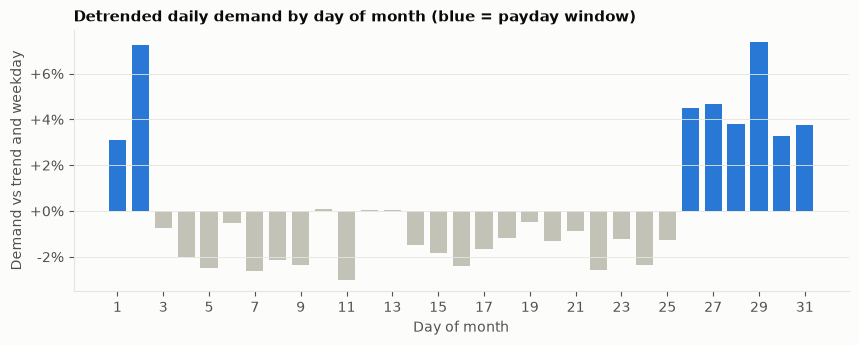

,mean,count
period,,
ordinary day,0.9849,214
payday window (26th – 2nd),1.0431,75


In [18]:
day = daily_index(d[d["zone"] != "Ayat"])
idx = day / day.rolling(29, center=True, min_periods=15).mean()
p = pd.DataFrame({"idx": idx, "dom": idx.index.day, "dim": idx.index.days_in_month, "dow": idx.index.dayofweek}).dropna()
p = p[~p.index.isin(holiday_dates)]
p["detrended"] = p["idx"] / p.groupby("dow")["idx"].transform("mean")
p["days_to_end"] = p["dim"] - p["dom"]
p["period"] = np.where((p["dom"] <= 2) | (p["days_to_end"] <= 5), "payday window (26th – 2nd)", "ordinary day")
b43 = p.groupby("period")["detrended"].agg(["mean", "count"])
t = stats.ttest_ind(p.loc[p["period"] != "ordinary day", "detrended"], p.loc[p["period"] == "ordinary day", "detrended"], equal_var=False)
effect = b43.loc["payday window (26th – 2nd)", "mean"] / b43.loc["ordinary day", "mean"] - 1
print(f"payday uplift {effect:+.1%} (Welch t = {t.statistic:.1f}, p = {t.pvalue:.1e})")
by_dom = p.groupby("dom")["detrended"].mean()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(by_dom.index, by_dom - 1, color=[BLUE if (dd <= 2 or dd >= 26) else NEUTRAL for dd in by_dom.index], width=0.75)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_xticks(range(1, 32, 2))
ax.set_xlabel("Day of month")
ax.set_ylabel("Demand vs trend and weekday")
ax.grid(axis="x", visible=False)
ax.set_title("Detrended daily demand by day of month (blue = payday window)")
plt.show()
b43.round(4)

**Interpretation.** Yes: after removing the trend and weekday effects, the payday window (26th to 2nd) runs 5.9% above ordinary days (Welch t = 10.1, p < 0.001), with the strongest days on the 29th and the 2nd. That is about 2 extra trips per zone-hour — smaller than the hour-of-day or rain effects but consistent and known in advance, so days_to_month_end is worth keeping as a feature.